In [1]:
from gn import solve_heat_eq
from helpers import *

u0_sat.min: 0.0
u0_sat.max: 4.499614479587919


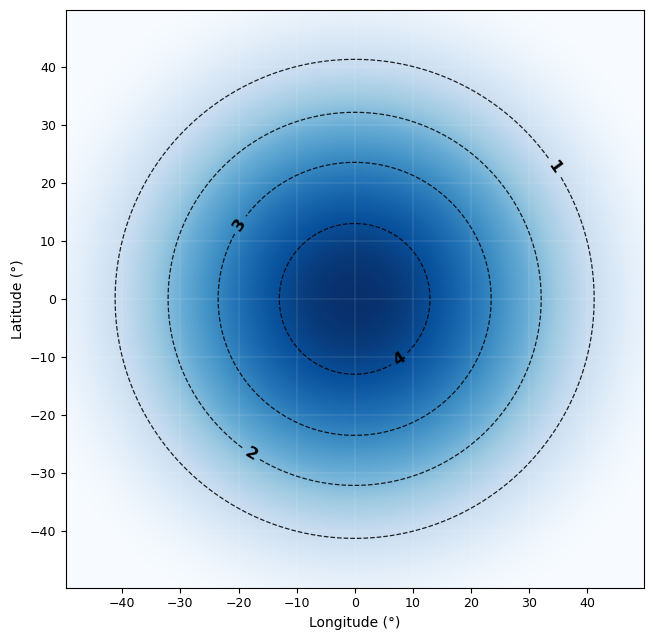

u0_doublegauss.min: 0.0
u0_doublegauss.max: 4.5


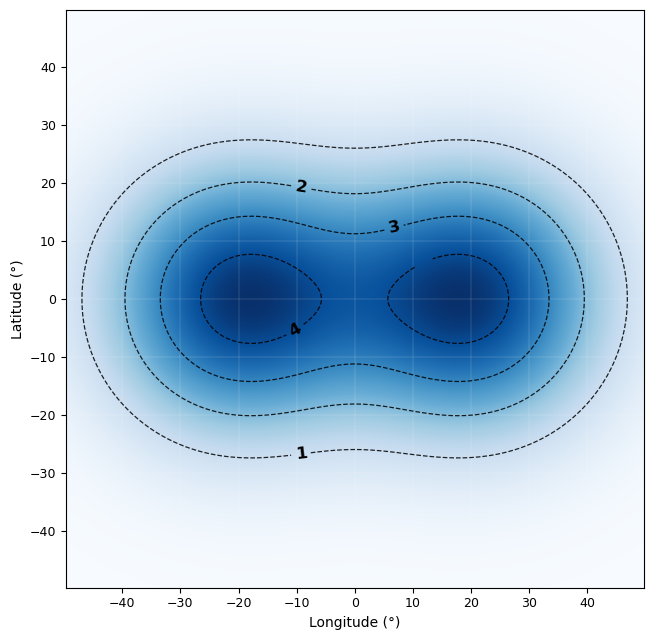

In [2]:
# initialize simulated densities
u0_sat, lons_sat, lats_sat = initial_meteosat_density()
print(f"u0_sat.min: {u0_sat.min()}")
print(f"u0_sat.max: {u0_sat.max()}")
fig, ax = plot_density_contour(u0_sat.T, lons_sat, lats_sat,
                               fontsize=12,
                               font_color='black',
                               line_color='black',
                               cmap='Blues')
plt.show()

u0_doublegauss, lons, lats = double_gaussian()
u0_doublegauss = scale_density(u0_doublegauss, target_min=0.0, target_max=4.5)
print(f"u0_doublegauss.min: {u0_doublegauss.min()}")
print(f"u0_doublegauss.max: {u0_doublegauss.max()}")

fig, ax = plot_density_contour(u0_doublegauss, lons_sat, lats_sat,
                               fontsize=12,
                               font_color='black',
                               line_color='black',
                               cmap='Blues')

u0_sat_shirley.min: 0.33145953872747014
u0_sat_shirley.max: 4.499614479587919
u0_doublegauss_shirley.min: 0.023603109840388808
u0_doublegauss_shirley.max: 4.499665747175603


(<Figure size 700x650 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

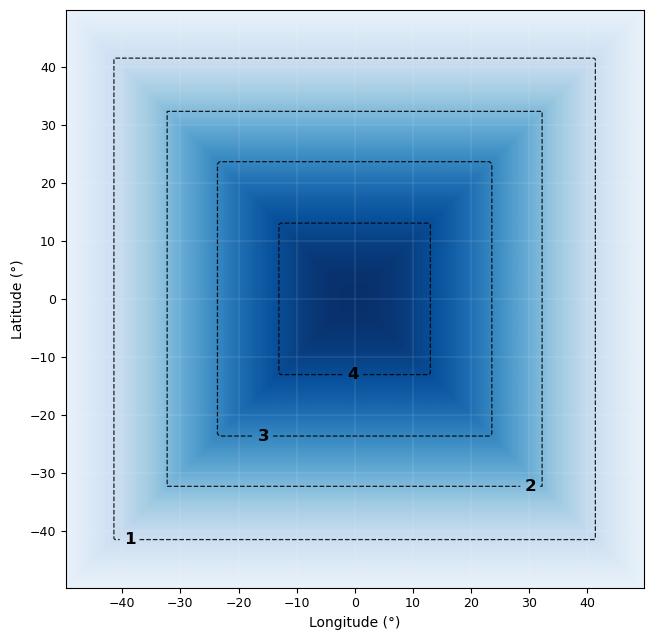

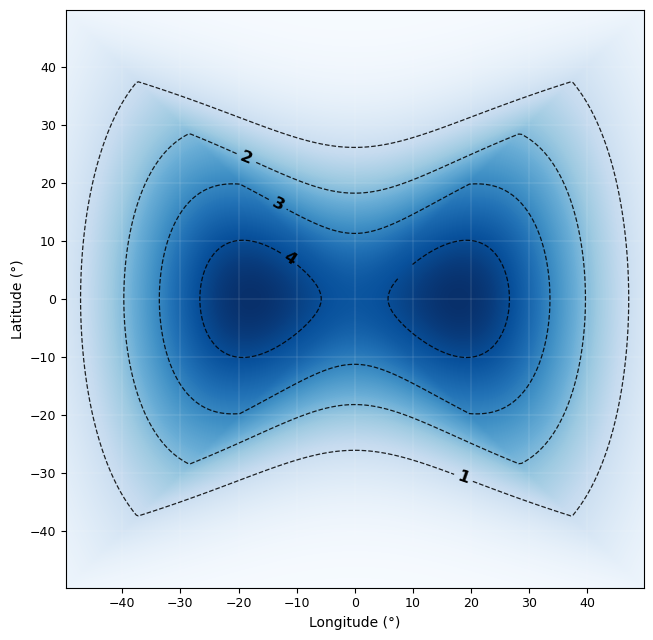

In [3]:
# apply the shirley mapping to move values to fill empty/zero-regions
# Note: GN and OT would otherwise not move anything to zero-density regions, the regions you want to fill must therefore contain very small, non-zero density values!
u0_sat_shirley = shirley_map_density_to_square(u0_sat)
print(f"u0_sat_shirley.min: {u0_sat_shirley.min()}")
print(f"u0_sat_shirley.max: {u0_sat_shirley.max()}")
plot_density_contour(u0_sat_shirley, lons, lats)

u0_doublegauss_shirley = shirley_map_density_to_square(u0_doublegauss)
print(f"u0_doublegauss_shirley.min: {u0_doublegauss_shirley.min()}")
print(f"u0_doublegauss_shirley.max: {u0_doublegauss_shirley.max()}")
plot_density_contour(u0_doublegauss_shirley, lons, lats)

u0_sat_shirley_blur.min: 0.3623496740165111
u0_sat_shirley_blur.max: 4.48828293081322
u0_doublegauss_shirley_blur.min: 0.030251969774024442
u0_doublegauss_shirley_blur.max: 4.473955892538646


(<Figure size 700x650 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

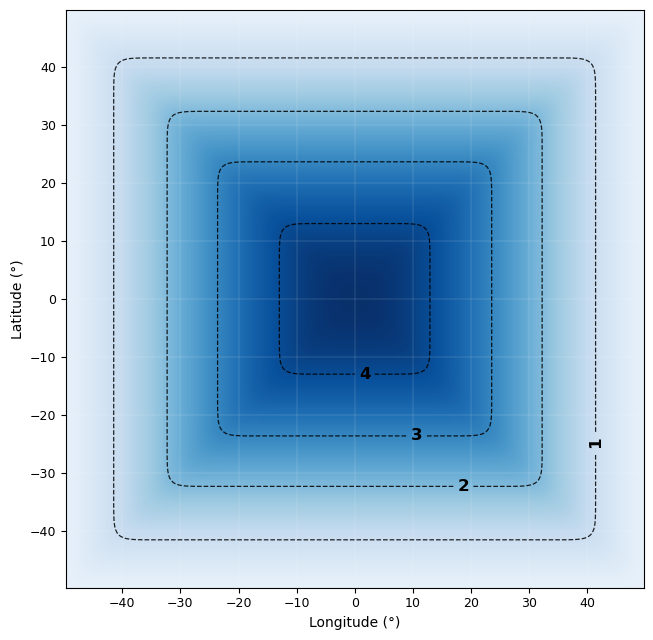

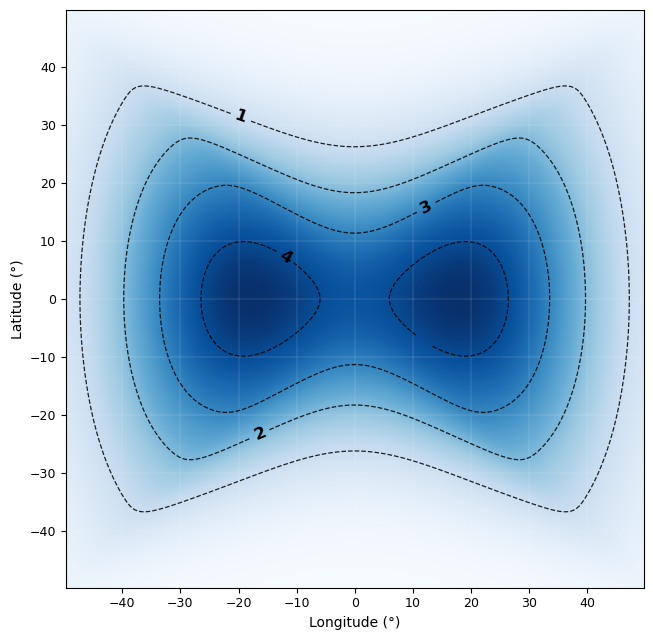

In [5]:
# apply the spectral blur and epsilon-floor
u0_sat_shirley_blur = spectral_gaussian_blur(u0_sat_shirley, blur_sigma=3.0, floor_eps=1e-3)
print(f"u0_sat_shirley_blur.min: {u0_sat_shirley_blur.min()}")
print(f"u0_sat_shirley_blur.max: {u0_sat_shirley_blur.max()}")
plot_density_contour(u0_sat_shirley_blur, lons, lats)


u0_doublegauss_shirley_blur = spectral_gaussian_blur(u0_doublegauss_shirley, blur_sigma=3.0, floor_eps=1e-3)
print(f"u0_doublegauss_shirley_blur.min: {u0_doublegauss_shirley_blur.min()}")
print(f"u0_doublegauss_shirley_blur.max: {u0_doublegauss_shirley_blur.max()}")
plot_density_contour(u0_doublegauss_shirley_blur, lons, lats)

In [6]:
# now after preparing the density, lets apply the Gastner-Newman algorithm to solve the heat equation for density equalisation
# Nx, Ny = 200, 200
Nx = u0_sat.shape[0]
Ny = u0_sat.shape[1]

sat_density_gn, dX_sat, dY_sat, vx_final_sat, vy_final_sat = solve_heat_eq(u0_sat_shirley_blur, Nx=Nx, Ny=Ny,
                                                                            eps=1e-10,
                                                                            min_t=1e3, max_t=1e12, 
                                                                            max_iter=10000, 
                                                                            verbose=True)
print(f"Equalised satellite density mean: {sat_density_gn.mean()}")


doublegauss_density_gn, dX_doublegauss, dY_doublegauss, vx_final_doublegauss, vy_final_doublegauss = solve_heat_eq(u0_doublegauss_shirley_blur, Nx=Nx, Ny=Ny,
                                                                                                                    eps=1e-10,
                                                                                                                    min_t=1e3, max_t=1e12, 
                                                                                                                    max_iter=10000, 
                                                                                                                    verbose=True)
print(f"Equalised doublegauss density mean: {doublegauss_density_gn.mean()}")

iter = 10, t = 1.594e-01, delta_t = 2.594e-02, max_change = 2.561e-06
iter = 20, t = 5.727e-01, delta_t = 6.727e-02, max_change = 1.687e-05
iter = 30, t = 1.645e+00, delta_t = 1.745e-01, max_change = 1.079e-04
iter = 40, t = 4.426e+00, delta_t = 4.526e-01, max_change = 6.544e-04
iter = 50, t = 1.164e+01, delta_t = 1.174e+00, max_change = 3.604e-03
iter = 60, t = 3.035e+01, delta_t = 3.045e+00, max_change = 1.746e-02
iter = 70, t = 7.887e+01, delta_t = 7.897e+00, max_change = 7.195e-02
iter = 80, t = 1.885e+02, delta_t = 1.536e+01, max_change = 1.433e-01
iter = 90, t = 3.616e+02, delta_t = 2.241e+01, max_change = 1.492e-01
iter = 100, t = 6.142e+02, delta_t = 3.270e+01, max_change = 1.600e-01
iter = 110, t = 9.827e+02, delta_t = 4.771e+01, max_change = 1.655e-01
iter = 120, t = 1.520e+03, delta_t = 6.961e+01, max_change = 1.244e-01
iter = 130, t = 2.263e+03, delta_t = 1.016e+02, max_change = 6.294e-02
iter = 140, t = 3.530e+03, delta_t = 1.976e+02, max_change = 2.128e-02
iter = 150, t =

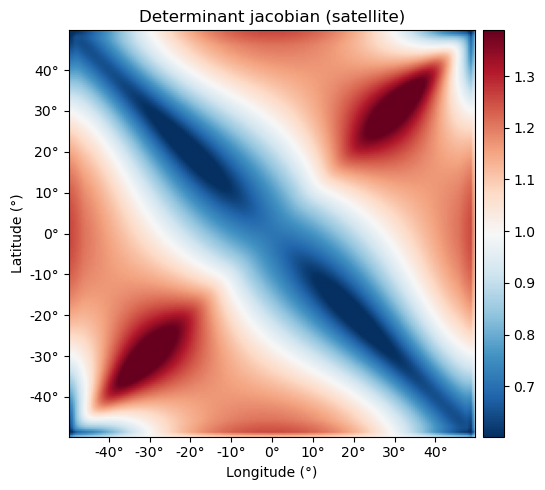

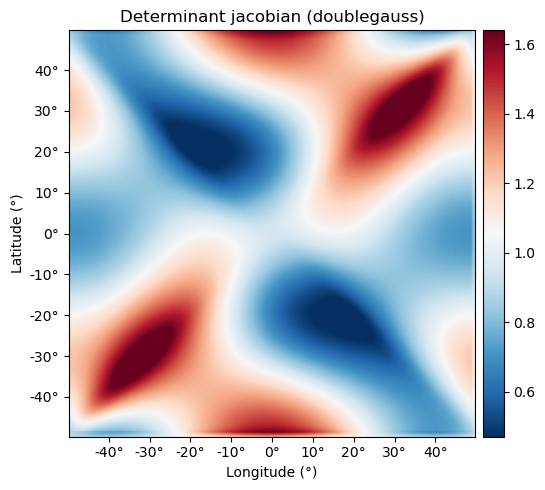

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Determinant jacobian (doublegauss)'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>)

In [7]:
# now lets look at the jacobian and the determinant jacobian of the displacements field to determine if folds were created
displacement_jacobian_sat = compute_jacobian(dX_sat, dY_sat)
det_J_sat = displacement_jacobian(dX_sat, dY_sat)
#plot_field(displacement_jacobian_sat, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Jacobian (satellite)")
plot_field(det_J_sat, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Determinant jacobian (satellite)")

displacement_jacobian_doublegauss = compute_jacobian(dX_doublegauss, dY_doublegauss)
det_J_doublegauss = displacement_jacobian(dX_doublegauss, dY_doublegauss)
#plot_field(displacement_jacobian_doublegauss, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Jacobian (doublegauss)")
plot_field(det_J_doublegauss, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Determinant jacobian (doublegauss)")